# COLO829 telomere-end analysis (T vs BL), PB and UL-ONT


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 1. Input files & filter

In [3]:
# enter your path here

BASE = 'your/base/dir'

TECHS = {
    'PB': [
        ('BL', os.path.join(BASE, 'COLO829-BL_pb.telo.center.txt.clean.gz')),
        ('T',  os.path.join(BASE, 'COLO829-T_pb.telo.center.txt.clean.gz')),
    ],
    'UL-ONT': [
        ('BL', os.path.join(BASE, 'COLO829-BL_UL-ONT-R10.all.sorted.tagged.telo.center.txt.clean.gz')),
        ('T',  os.path.join(BASE, 'COLO829-T-PassageB_UL-ONT-R10.all.sorted.tagged.telo.center.txt.clean.gz')),
    ],
}

MIN_SUBTELO_BP = 5_000   # require centered_query_start < -MIN_SUBTELO_BP
MIN_TELO_BP    = 500     # require centered_query_end   >  MIN_TELO_BP
OUT_DIR = BASE

## 2. Load & filter helper


In [4]:
FT_CENTER_COLS = [
    'chrom', 'centering_position', 'strand', 'subset_sequence',
    'reference_start', 'reference_end', 'query_name', 'RG', 'HP',
    'centered_query_start', 'centered_query_end', 'query_length',
    'query_sequence',
]

def load_and_filter(path, sample_label,
                    min_subtelo_bp=MIN_SUBTELO_BP,
                    min_telo_bp=MIN_TELO_BP):
    df = pd.read_csv(
        path, sep='\t', header=None, skiprows=1,
        usecols=list(range(13)), names=FT_CENTER_COLS,
    )
    for c in ('centering_position', 'centered_query_start', 'centered_query_end'):
        df[c] = df[c].astype(int)

    # one row per molecule per end
    df = (df.groupby(['chrom', 'centering_position', 'query_name'], sort=False)
            .agg(centered_query_start=('centered_query_start', 'min'),
                 centered_query_end=('centered_query_end', 'max'))
            .reset_index())

    # filter
    df = df[(df['centered_query_start'] < -min_subtelo_bp) &
            (df['centered_query_end']   >  min_telo_bp)].copy()
    df['sample'] = sample_label
    return df

## 3. Per-technology pipeline


In [5]:
def _per_end_summary(reads):
    return (reads.groupby(['sample', 'chrom', 'centering_position'])
                  .agg(n_reads=('query_name', 'nunique'),
                       median_telo_len=('centered_query_end', 'median'))
                  .reset_index()
                  .sort_values(['chrom', 'centering_position', 'sample'])
                  .reset_index(drop=True))

def _wide(summary):
    w = summary.pivot_table(
        index=['chrom', 'centering_position'],
        columns='sample',
        values=['n_reads', 'median_telo_len'],
    )
    w.columns = [f'{m}_{s}' for m, s in w.columns]
    w = w.reset_index()
    ordered = ['chrom', 'centering_position']
    for metric in ['n_reads', 'median_telo_len']:
        for s in ['BL', 'T']:
            col = f'{metric}_{s}'
            if col in w.columns:
                ordered.append(col)
    return w[ordered].sort_values(['chrom', 'centering_position']).reset_index(drop=True)

def _plots(paired, tech_name):
    if len(paired) == 0:
        print(f'[{tech_name}] no paired ends; skipping plots')
        return

    # 1. T vs BL scatter
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.scatter(paired['median_telo_len_BL'], paired['median_telo_len_T'],
               s=28, alpha=0.85, color='#4c72b0',
               edgecolor='black', linewidth=0.4)
    hi = float(max(paired['median_telo_len_BL'].max(),
                   paired['median_telo_len_T'].max())) * 1.05
    ax.plot([0, hi], [0, hi], color='k', lw=0.7, ls='--', alpha=0.6, zorder=0)
    ax.set_xlim(0, hi); ax.set_ylim(0, hi)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('BL  median telomere length (bp)')
    ax.set_ylabel('T  median telomere length (bp)')
    ax.set_title(f'[{tech_name}] Per-end median telomere length (n={len(paired)})')
    plt.tight_layout(); plt.show()

    # 2. per-end delta(T − BL)
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(paired))
    colors = np.where(paired['delta_T_minus_BL'] >= 0, '#c44e52', '#4c72b0')
    ax.bar(x, paired['delta_T_minus_BL'], color=colors,
           edgecolor='black', linewidth=0.3)
    ax.axhline(0, color='k', lw=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f'{c}@{p}' for c, p in zip(paired['chrom'], paired['centering_position'])],
        rotation=90, fontsize=5,
    )
    ax.set_ylabel('Median telomere length: T \u2212 BL (bp)')
    ax.set_title(f'[{tech_name}] Per-end change in median telomere length (T \u2212 BL), n={len(paired)}')
    plt.tight_layout(); plt.show()

    # 3. paired strip plot
    fig, ax = plt.subplots(figsize=(4, 5))
    rng = np.random.default_rng(0)
    for i, s in enumerate(['BL', 'T']):
        vals = paired[f'median_telo_len_{s}'].values
        jitter = rng.uniform(-0.1, 0.1, size=len(vals))
        ax.scatter(np.full_like(vals, i, dtype=float) + jitter, vals,
                   s=24, alpha=0.85, color='#4c72b0',
                   edgecolor='black', linewidth=0.4)
        ax.hlines(np.median(vals), i - 0.25, i + 0.25, color='k', lw=1.8)
    for _, r in paired.iterrows():
        ax.plot([0, 1], [r['median_telo_len_BL'], r['median_telo_len_T']],
                color='lightgray', lw=0.4, alpha=0.6, zorder=0)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['BL', 'T'])
    ax.set_ylabel('Median telomere length per end (bp)')
    ax.set_ylim(0,15_000)
    ax.set_title(f'[{tech_name}] Per-end medians, paired (n={len(paired)})')
    plt.tight_layout()
    plt.savefig(f'{tech_name}_Per-end_medians_paired.pdf')
    plt.show()

def run_tech(tech_name, sample_list, out_dir=OUT_DIR):
    print(f'\n========== {tech_name} ==========')
    reads = pd.concat(
        [load_and_filter(p, lbl) for lbl, p in sample_list],
        ignore_index=True,
    )
    print(f'After filter (start < -{MIN_SUBTELO_BP} AND end > {MIN_TELO_BP}):')
    for lbl, _ in sample_list:
        sub = reads[reads['sample'] == lbl]
        print(f'  {lbl}: {len(sub)} molecules across '
              f'{sub.groupby(["chrom", "centering_position"]).ngroups} ends')

    summary = _per_end_summary(reads)
    wide    = _wide(summary)

    # sample-wide read-level medians
    smed = (reads.groupby('sample')
                 .agg(n_reads=('centered_query_end', 'size'),
                      median_telo_len=('centered_query_end', 'median'),
                      mean_telo_len=('centered_query_end', 'mean')))
    print('\nSample-wide read-level telomere length:')
    print(smed)
    if {'BL', 'T'}.issubset(smed.index):
        print(f'  Δ(T - BL) median = {smed.loc["T","median_telo_len"] - smed.loc["BL","median_telo_len"]:+.1f} bp')

    # end overlap (every surviving end is "resolved")
    bl_ends = set(zip(summary.loc[summary["sample"]=="BL", "chrom"],
                      summary.loc[summary["sample"]=="BL", "centering_position"]))
    t_ends  = set(zip(summary.loc[summary["sample"]=="T",  "chrom"],
                      summary.loc[summary["sample"]=="T",  "centering_position"]))
    shared = bl_ends & t_ends
    print(f'\nResolved ends — BL: {len(bl_ends)}, T: {len(t_ends)}, '
          f'shared: {len(shared)}, BL-only: {len(bl_ends-t_ends)}, T-only: {len(t_ends-bl_ends)}')
    if t_ends:
        print(f'Proportion of T-resolved also in BL: {len(shared)}/{len(t_ends)} = {len(shared)/len(t_ends):.3f}')

    # paired delta
    paired = wide.dropna(subset=['median_telo_len_BL', 'median_telo_len_T']).copy()
    paired['delta_T_minus_BL'] = paired['median_telo_len_T'] - paired['median_telo_len_BL']
    paired = paired.sort_values('delta_T_minus_BL').reset_index(drop=True)
    if len(paired):
        print(f'\nPaired ends (in both BL and T): {len(paired)}')
        print(f'  median Δ(T - BL)     = {paired["delta_T_minus_BL"].median():+.1f} bp')
        print(f'  T longer at {(paired["delta_T_minus_BL"] > 0).sum()} ends, '
              f'BL longer at {(paired["delta_T_minus_BL"] < 0).sum()} ends, '
              f'tied at {(paired["delta_T_minus_BL"] == 0).sum()} ends')

    _plots(paired, tech_name)

    # write CSVs (tech name in filename)
    suffix = tech_name.lower().replace('-', '_')
    long_csv   = os.path.join(out_dir, f'colo829_{suffix}_per_end_counts_long.csv')
    wide_csv   = os.path.join(out_dir, f'colo829_{suffix}_per_end_counts_wide.csv')
    paired_csv = os.path.join(out_dir, f'colo829_{suffix}_per_end_paired_medians.csv')
    summary.to_csv(long_csv, index=False)
    wide.to_csv(wide_csv, index=False)
    paired.to_csv(paired_csv, index=False)
    print('\nWrote:')
    for p in (long_csv, wide_csv, paired_csv):
        print(' ', p)

    return {'reads': reads, 'summary': summary, 'wide': wide, 'paired': paired,
            'sample_medians': smed}

## 4. Run for each technology

In [6]:
results = {}
for tech_name, sample_list in TECHS.items():
    results[tech_name] = run_tech(tech_name, sample_list)


========== PB ==========


FileNotFoundError: [Errno 2] No such file or directory: 'your/base/dir/COLO829-BL_pb.telo.center.txt.clean.gz'

## 5. Cross-technology comparison


In [ ]:
rows = []
for tech_name, r in results.items():
    s = r['sample_medians'].reset_index()
    s.insert(0, 'technology', tech_name)
    rows.append(s)
all_sample_medians = pd.concat(rows, ignore_index=True)
all_sample_medians

## 6. Read-level telomere-length distributions (BL vs T)



Empty DataFrame
Columns: []
Index: []



ValueError: List of boxplot statistics and `positions` values must have same the length

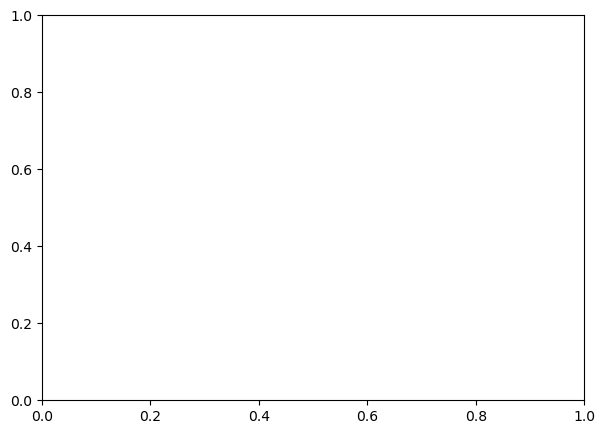

In [7]:
from scipy.stats import mannwhitneyu

def _pull(tech, sample):
    df = results[tech]['reads']
    return df.loc[df['sample'] == sample, 'centered_query_end'].to_numpy()

# Per-tech statistics: medians, ΔT-BL, Mann-Whitney U
stats_rows = []
for tech in results:
    bl = _pull(tech, 'BL')
    t  = _pull(tech, 'T')
    med_bl = float(np.median(bl)) if len(bl) else float('nan')
    med_t  = float(np.median(t))  if len(t)  else float('nan')
    if len(bl) > 0 and len(t) > 0:
        u, p = mannwhitneyu(bl, t, alternative='two-sided')
    else:
        u, p = float('nan'), float('nan')
    stats_rows.append({
        'technology': tech,
        'n_BL': int(len(bl)), 'n_T': int(len(t)),
        'median_BL_bp': med_bl,
        'median_T_bp':  med_t,
        'median_delta_T_minus_BL_bp': med_t - med_bl,
        'mannwhitneyu_U': float(u),
        'mannwhitneyu_p': float(p),
    })
stats_df = pd.DataFrame(stats_rows)
print(stats_df.to_string(index=False))
print()
for _, r in stats_df.iterrows():
    print(f"{r['technology']:<7}  median(BL)={r['median_BL_bp']:.1f}  "
          f"median(T)={r['median_T_bp']:.1f}  "
          f"Δ(T-BL)={r['median_delta_T_minus_BL_bp']:+.1f} bp  "
          f"U={r['mannwhitneyu_U']:.0f}  p={r['mannwhitneyu_p']:.3e}")

# Combined boxplot: BL & T for each tech
fig, ax = plt.subplots(figsize=(7, 5))
techs = list(results.keys())
positions, data, labels, colors = [], [], [], []
sample_colors = {'BL': '#4c72b0', 'T': '#c44e52'}
within_gap, group_gap = 0.7, 1.0
x = 0.0
for tech in techs:
    for sample in ['BL', 'T']:
        data.append(_pull(tech, sample))
        positions.append(x)
        labels.append(f'{tech}\n{sample}')
        colors.append(sample_colors[sample])
        x += within_gap
    x += group_gap
bp = ax.boxplot(data, positions=positions, widths=0.5, patch_artist=True,
                showfliers=False, whis=(10, 90))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_edgecolor('black'); patch.set_alpha(0.85)
for med in bp['medians']:
    med.set(color='black', linewidth=1.5)
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Telomere length (bp)  —  centered_query_end')

# Build two stats lines for the title, one segment per tech
stats_line_1 = '   '.join(
    f"{r['technology']}: Δ={r['median_delta_T_minus_BL_bp']:+.0f} bp"
    for _, r in stats_df.iterrows()
)
stats_line_2 = '   '.join(
    f"{r['technology']}: U={r['mannwhitneyu_U']:.0f}, p={r['mannwhitneyu_p']:.2e}"
    for _, r in stats_df.iterrows()
)
ax.set_title(
    'Per-read telomere length distributions across all molecules\n'
    + stats_line_1 + '\n' + stats_line_2,
    fontsize=10
)

ax.set_ylim(0, 10_000)
plt.tight_layout()
out_pdf = os.path.join(OUT_DIR, 'colo829_telomere_length_boxplot.pdf')
out_csv = os.path.join(OUT_DIR, 'colo829_telomere_length_mannwhitney.csv')
# plt.savefig(out_pdf, dpi=200)
plt.show()
stats_df.to_csv(out_csv, index=False)
print(f'\nWrote {out_pdf}')
print(f'Wrote {out_csv}')